# Qwen3 Dream Continuation — VS Code Interactive Notebook + Evaluation Graphs

This notebook is designed for the post-training phase.

It has two roles:

1. **Visualization notebook**: load the CSV outputs produced by `quattro_modelli` and create graphs for NLL, perplexity, and embedding similarity.
2. **Interactive generation notebook**: load one of the four model variants and generate dream continuations.

The heavy computation is done in `quattro_modelli`; this notebook mainly reads the exported CSV files and plots them.


## 1. Install packages

Run this cell once. If you already installed these packages in your environment, you can skip it.

Important notes:

- On a local Windows machine, `bitsandbytes` may not work correctly. The notebook automatically falls back to non-4-bit loading if 4-bit is not available.
- If you have an NVIDIA GPU, generation will be much faster.
- If you only have CPU, the notebook can still run, but generation may be slow.

In [1]:
%pip install -U "transformers>=4.51.0" "accelerate" "peft" "pandas" "gradio" "safetensors" "tqdm" "matplotlib"


Note: you may need to restart the kernel to use updated packages.


## 2. Configuration: set your local file paths

Edit only this cell if your files have different names or are stored in different folders.

In [2]:
from pathlib import Path

# ============================================================
# Main model and local files
# ============================================================
BASE_MODEL_NAME = "Qwen/Qwen3-1.7B-Base"

# Zip created by the fine-tuning/evaluation notebook.
ADAPTER_ZIP_PATH = Path("qwen3_dream_metadata_lora_adapters.zip")

# Optional dataset used only to recover metadata values and sample dream starts.
DREAM_CSV_PATH = Path("dream_clean_emotion_topic_metadata.csv")

# Optional evaluation outputs already created by the previous notebook.
RESULTS_CSV_PATH = Path("qwen3_dream_four_model_metadata_evaluation_results.csv")
SUMMARY_CSV_PATH = Path("qwen3_dream_four_model_metadata_summary.csv")
PAIRWISE_CSV_PATH = Path("qwen3_dream_four_model_metadata_pairwise_comparisons.csv")
SEMANTIC_CSV_PATH = Path("qwen3_dream_four_model_metadata_semantic_similarity.csv")

# Expected adapter folder names inside the zip.
ADAPTER_A_NAME = "final_A_no_metadata"
ADAPTER_B_NAME = "final_B_with_metadata"

# Common extraction folder used by the old notebook.
FINETUNED_ROOT = Path("qwen3_dream_cv_final_outputs")

# Dataset column candidates.
TEXT_COL_CANDIDATES = ["dream_text", "text_dream", "dream", "text", "report"]

# All metadata fields selectable in the interface and inserted in the metadata prompt.
METADATA_COLS = [
    "dominant_macro_emotion",
    "second_dominant_macro_emotion",
    "dream_topic",
    "sex",
    "age",
]

# Generation settings.
MAX_LENGTH = 768
DEFAULT_MAX_NEW_TOKENS = 140
DEFAULT_TEMPERATURE = 0.80
DEFAULT_TOP_P = 0.90
DEFAULT_REPETITION_PENALTY = 1.08

# Keep True if you have a CUDA GPU and bitsandbytes works. The notebook will fallback if not available.
USE_4BIT = True

# If you have memory issues, keep this True so only one selected model is kept in memory.
LOAD_ONE_MODEL_AT_A_TIME = True

In [3]:
# import sys

# !{sys.executable} -m pip uninstall torch torchvision torchaudio -y
# !{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

## 3. Imports and basic environment check

In [4]:
import os
import gc
import json
import zipfile
import shutil
from typing import Optional, Dict, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import gradio as gr
from IPython.display import display

from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
from peft import PeftModel

try:
    from transformers import BitsAndBytesConfig
except Exception:
    BitsAndBytesConfig = None

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

SEED = 42
set_seed(SEED)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("bfloat16 supported:", torch.cuda.is_bf16_supported())
else:
    print("Running without CUDA. Generation may be slow.")

Torch version: 2.12.1+cu126
CUDA available: True
GPU: NVIDIA GeForce MX350
bfloat16 supported: True


## 4. Load optional CSV outputs from the previous notebook

These files are **not necessary for generation**, but they are useful for showing the evaluation results inside this notebook.

In [5]:
def load_optional_csv(path: Path, name: str) -> Optional[pd.DataFrame]:
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded {name}: {path} | shape={df.shape}")
        return df
    print(f"Not found: {name} -> {path}")
    return None

results_df = load_optional_csv(RESULTS_CSV_PATH, "full evaluation results")
summary_df = load_optional_csv(SUMMARY_CSV_PATH, "summary results")
pairwise_df = load_optional_csv(PAIRWISE_CSV_PATH, "pairwise comparisons")
semantic_df = load_optional_csv(SEMANTIC_CSV_PATH, "semantic similarity table")

# Backward compatibility: if the separate semantic file is missing, use the detailed results file.
if semantic_df is None and results_df is not None and "embedding_cosine_similarity" in results_df.columns:
    semantic_df = results_df.copy()
    print("Using semantic columns from full evaluation results.")

if summary_df is not None:
    print("\nSummary results:")
    display(summary_df)

if pairwise_df is not None:
    print("\nPairwise comparisons:")
    display(pairwise_df)

if semantic_df is not None and "embedding_cosine_similarity" in semantic_df.columns:
    print("\nSemantic similarity preview:")
    display(semantic_df.head())


Loaded full evaluation results: qwen3_dream_four_model_metadata_evaluation_results.csv | shape=(1200, 27)
Loaded summary results: qwen3_dream_four_model_metadata_summary.csv | shape=(4, 17)
Loaded pairwise comparisons: qwen3_dream_four_model_metadata_pairwise_comparisons.csv | shape=(5, 15)
Loaded semantic similarity table: qwen3_dream_four_model_metadata_semantic_similarity.csv | shape=(1200, 10)

Summary results:


,model_variant,n_examples,total_target_tokens,mean_avg_nll,median_avg_nll,weighted_avg_nll,mean_ppl,median_ppl,weighted_perplexity,n_semantic_examples,mean_embedding_similarity,median_embedding_similarity,std_embedding_similarity,mean_embedding_distance,share_embedding_similarity_ge_0_50,share_embedding_similarity_ge_0_70,mean_generated_to_target_word_ratio
0,finetuned_with_metadata,300,16714,2.753428,2.717788,2.784761,17.677802,15.146778,16.195953,300,0.600394,0.599356,0.090246,0.399606,0.840000,0.143333,0.467192
1,finetuned_no_metadata,300,16714,2.755634,2.717669,2.785777,17.725330,15.144975,16.212405,300,0.599049,0.599640,0.089238,0.400951,0.860000,0.140000,0.481165
2,base_no_metadata,300,16714,3.183665,3.113346,3.145519,27.433567,22.496201,23.231729,300,0.629547,0.632125,0.087299,0.370453,0.936667,0.206667,1.320875
3,base_with_metadata,300,16714,3.205919,3.130174,3.159219,28.047437,22.878006,23.552183,300,0.630408,0.640753,0.092517,0.369592,0.903333,0.250000,1.307439



Pairwise comparisons:


,comparison,first_model,second_model,n_examples,mean_nll_first,mean_nll_second,mean_nll_gain,median_nll_gain,share_examples_second_better,n_semantic_examples,mean_embedding_similarity_first,mean_embedding_similarity_second,mean_embedding_similarity_gain,median_embedding_similarity_gain,share_examples_second_better_embedding
0,Metadata effect on base model,base_no_metadata,base_with_metadata,300,3.183665,3.205919,-0.022253,-0.015970,0.316667,300,0.629547,0.630408,0.000862,0.000386,0.503333
1,Fine-tuning effect without metadata,base_no_metadata,finetuned_no_metadata,300,3.183665,2.755634,0.428032,0.366463,1.000000,300,0.629547,0.599049,-0.030498,-0.029640,0.360000
2,Fine-tuning effect with metadata,base_with_metadata,finetuned_with_metadata,300,3.205919,2.753428,0.452491,0.376421,1.000000,300,0.630408,0.600394,-0.030015,-0.029066,0.383333
3,Metadata + fine-tuning total effect,base_no_metadata,finetuned_with_metadata,300,3.183665,2.753428,0.430238,0.360527,1.000000,300,0.629547,0.600394,-0.029153,-0.025037,0.376667
4,Metadata effect after fine-tuning,finetuned_no_metadata,finetuned_with_metadata,300,2.755634,2.753428,0.002206,0.003958,0.560000,300,0.599049,0.600394,0.001345,0.000000,0.446667



Semantic similarity preview:


,row_id,model_variant,target_continuation,generated_continuation,embedding_cosine_similarity,embedding_distance,target_word_count,generated_word_count,generated_to_target_word_ratio,generation_error
0,0,base_no_metadata,biting it. I swing my arm away and he is throw...,and pulls it out quickly. The man has a knife ...,0.471566,0.528434,58,35,0.603448,NaN
1,1,base_no_metadata,"it was just one, but as I tried to put it back...",Jeremy and I were sitting in a café together w...,0.503050,0.496950,16,36,2.250000,NaN
2,2,base_no_metadata,The problems continued. Then I tried to get th...,"The next day, when I went back to my office, t...",0.727632,0.272368,21,35,1.666667,NaN
3,3,base_no_metadata,"his right hand between an arrow and a tree."" W...",a bad dream about the death of my father and m...,0.488436,0.511564,21,36,1.714286,NaN
4,4,base_no_metadata,do about it and I was really frustrated and th...,and it's just so hard to write with that thing...,0.460822,0.539178,38,44,1.157895,NaN


## 5. Evaluation graphs for the presentation

Run these cells after placing the CSV files exported by `quattro_modelli` in the same folder as this notebook.

These graphs are based only on the exported CSV files, so they do **not** reload the language model and do **not** redo the heavy evaluation.


In [ ]:


MODEL_LABELS = {
    "base_no_metadata": "Base\nNo metadata",
    "base_with_metadata": "Base\nWith metadata",
    "finetuned_no_metadata": "Fine-tuned\nNo metadata",
    "finetuned_with_metadata": "Fine-tuned\nWith metadata",
}

MODEL_ORDER = [
    "base_no_metadata",
    "base_with_metadata",
    "finetuned_no_metadata",
    "finetuned_with_metadata",
]


def _label_models(series):
    return series.map(MODEL_LABELS).fillna(series)


def _available(df, cols):
    return df is not None and all(col in df.columns for col in cols)


def _sort_summary_for_plot(df, metric, ascending=True):
    plot_df = df.copy()
    if "model_variant" in plot_df.columns:
        plot_df["model_order"] = plot_df["model_variant"].apply(
            lambda x: MODEL_ORDER.index(x) if x in MODEL_ORDER else len(MODEL_ORDER)
        )
        plot_df = plot_df.sort_values("model_order")
    else:
        plot_df = plot_df.sort_values(metric, ascending=ascending)
    return plot_df


def plot_summary_bar(metric, title, ylabel, lower_is_better=True):
    if not _available(summary_df, ["model_variant", metric]):
        print(f"Cannot plot {metric}: required columns are missing.")
        return

    plot_df = _sort_summary_for_plot(summary_df.dropna(subset=[metric]), metric, ascending=lower_is_better)
    if plot_df.empty:
        print(f"Cannot plot {metric}: no non-missing values.")
        return

    plt.figure(figsize=(9, 5))
    plt.bar(_label_models(plot_df["model_variant"]), plot_df[metric])
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_pairwise_bar(metric, title, ylabel, positive_message):
    if not _available(pairwise_df, ["comparison", metric]):
        print(f"Cannot plot {metric}: required columns are missing.")
        return

    plot_df = pairwise_df.dropna(subset=[metric]).copy()
    if plot_df.empty:
        print(f"Cannot plot {metric}: no non-missing values.")
        return

    plt.figure(figsize=(10, 5))
    plt.barh(plot_df["comparison"], plot_df[metric])
    plt.axvline(0, linewidth=1)
    plt.xlabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    print(positive_message)


def plot_distribution(metric, title, ylabel):
    source_df = semantic_df if semantic_df is not None else results_df

    if not _available(source_df, ["model_variant", metric]):
        print(f"Cannot plot {metric}: required columns are missing.")
        return

    plot_df = source_df.dropna(subset=[metric]).copy()
    if plot_df.empty:
        print(f"Cannot plot {metric}: no non-missing values.")
        return

    grouped_values = []
    labels = []

    for model in MODEL_ORDER:
        values = plot_df.loc[plot_df["model_variant"].eq(model), metric].dropna().values
        if len(values) > 0:
            grouped_values.append(values)
            labels.append(MODEL_LABELS.get(model, model))

    if not grouped_values:
        print(f"Cannot plot {metric}: no grouped values.")
        return

    plt.figure(figsize=(9, 5))
    plt.boxplot(grouped_values, tick_labels=labels, showmeans=True)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_nll_vs_similarity():
    source_df = results_df

    if not _available(source_df, ["model_variant", "avg_nll", "embedding_cosine_similarity"]):
        print("Cannot plot NLL vs embedding similarity: required columns are missing.")
        return

    plot_df = source_df.dropna(subset=["avg_nll", "embedding_cosine_similarity"]).copy()
    if plot_df.empty:
        print("Cannot plot NLL vs embedding similarity: no non-missing values.")
        return

    plt.figure(figsize=(8, 5))
    for model in MODEL_ORDER:
        subset = plot_df[plot_df["model_variant"].eq(model)]
        if len(subset) > 0:
            plt.scatter(
                subset["avg_nll"],
                subset["embedding_cosine_similarity"],
                alpha=0.55,
                label=MODEL_LABELS.get(model, model).replace("\n", " "),
            )

    plt.xlabel("Average NLL per target token")
    plt.ylabel("Embedding cosine similarity")
    plt.title("Token likelihood vs semantic similarity")
    plt.legend()
    plt.tight_layout()
    plt.show()
    


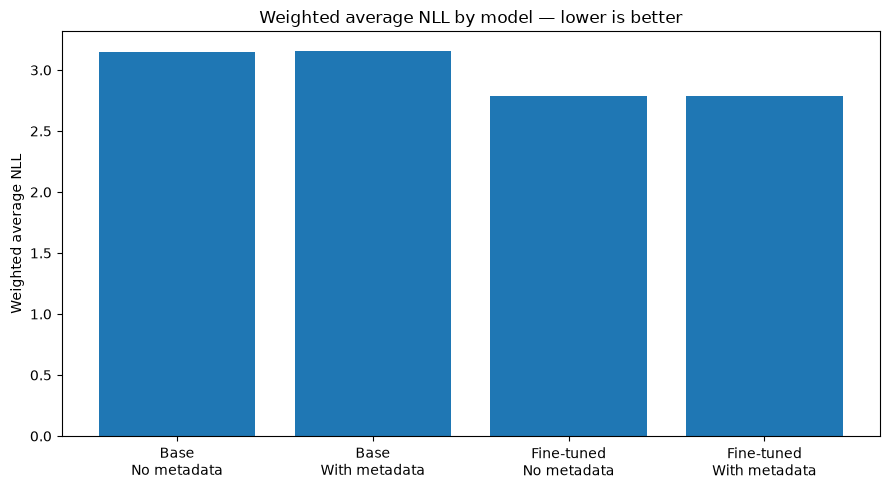

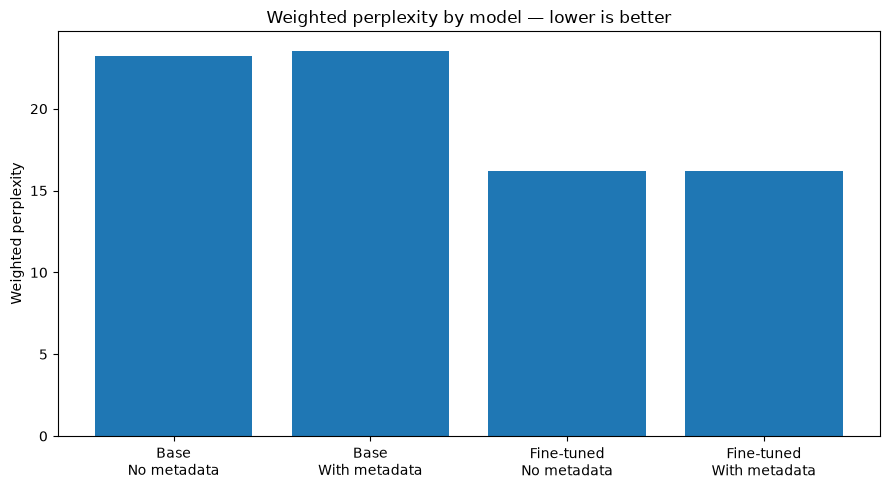

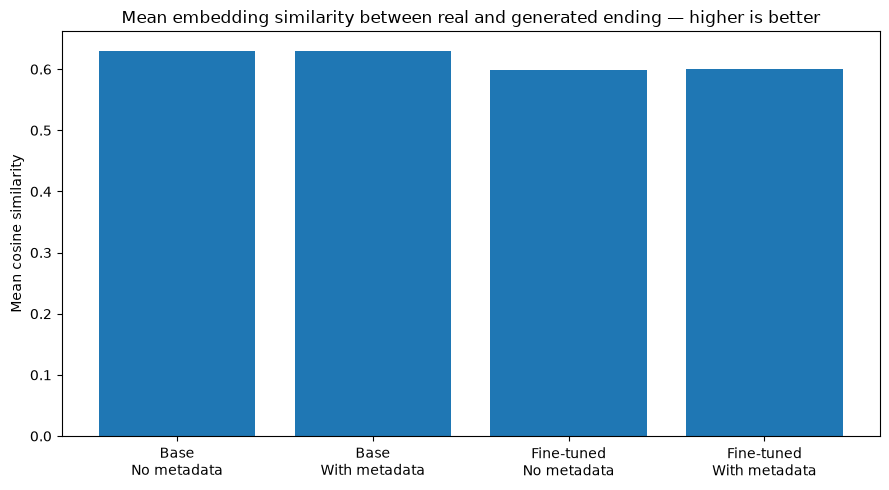

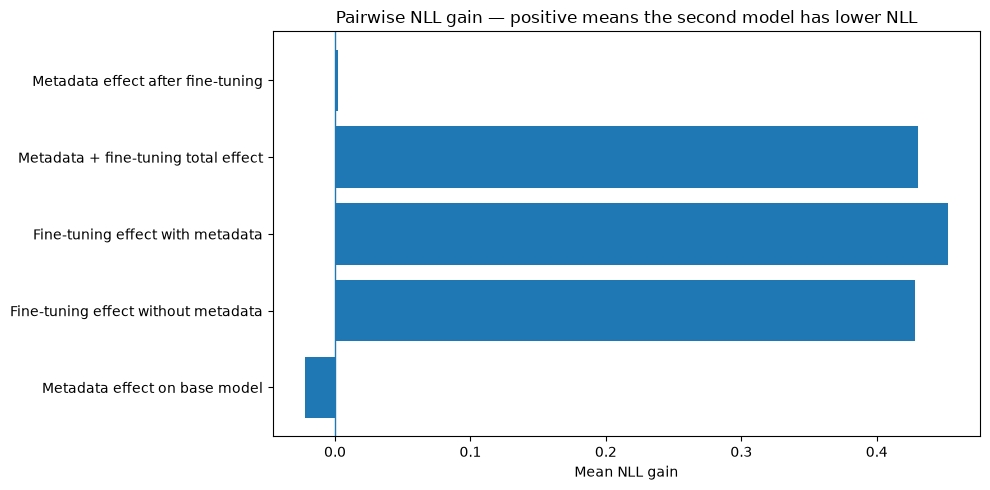

Positive values mean the second model in the comparison assigns higher probability to the true ending.


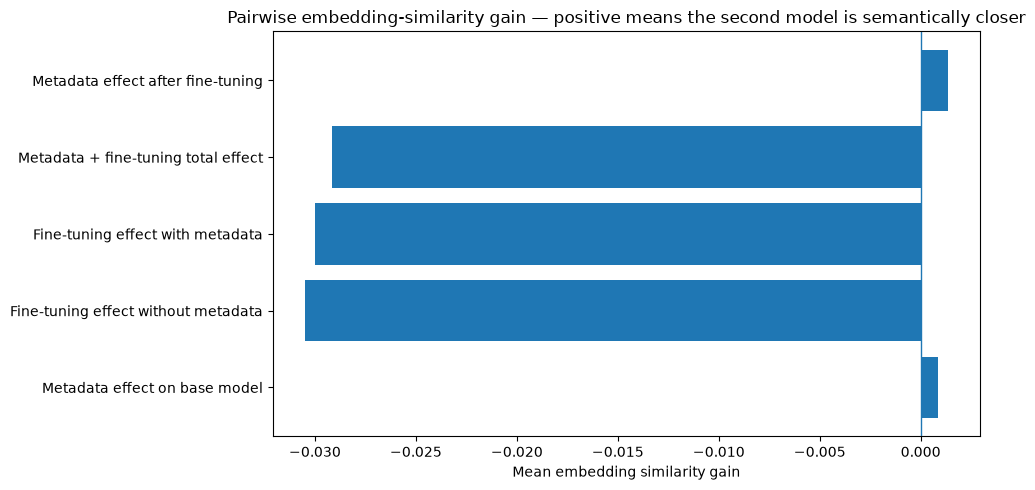

Positive values mean the second model generated endings that are semantically closer to the true endings.
Cannot plot avg_nll: required columns are missing.


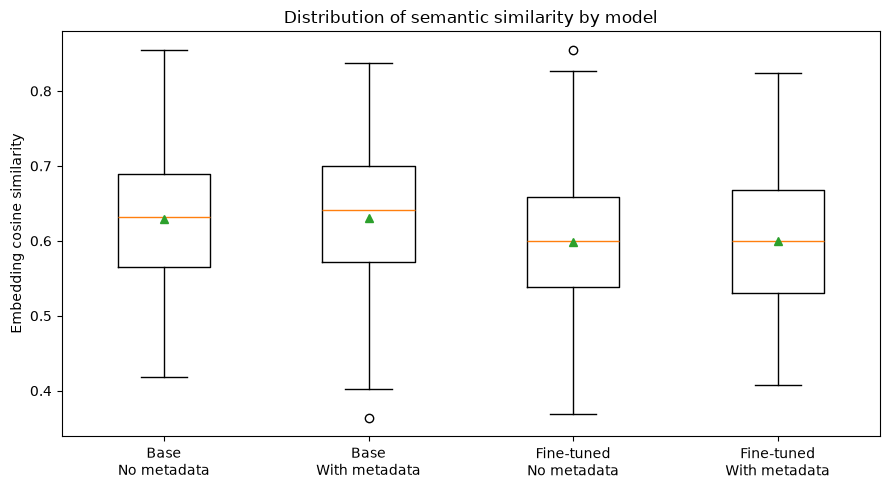

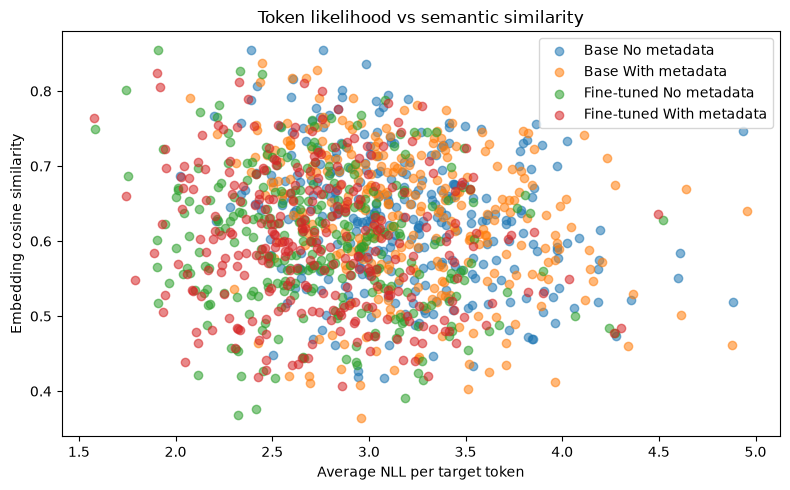

In [ ]:

# 1. Main probabilistic metrics.
plot_summary_bar(
    metric="weighted_avg_nll",
    title="Weighted average NLL by model — lower is better",
    ylabel="Weighted average NLL",
    lower_is_better=True,
)

plot_summary_bar(
    metric="weighted_perplexity",
    title="Weighted perplexity by model — lower is better",
    ylabel="Weighted perplexity",
    lower_is_better=True,
)

# 2. Main semantic metric.
plot_summary_bar(
    metric="mean_embedding_similarity",
    title="Mean embedding similarity between real and generated ending — higher is better",
    ylabel="Mean cosine similarity",
    lower_is_better=False,
)

# 3. Pairwise improvements.
plot_pairwise_bar(
    metric="mean_nll_gain",
    title="Pairwise NLL gain — positive means the second model has lower NLL",
    ylabel="Mean NLL gain",
    positive_message="Positive values mean the second model in the comparison assigns higher probability to the true ending.",
)

plot_pairwise_bar(
    metric="mean_embedding_similarity_gain",
    title="Pairwise embedding-similarity gain — positive means the second model is semantically closer",
    ylabel="Mean embedding similarity gain",
    positive_message="Positive values mean the second model generated endings that are semantically closer to the true endings.",
)

# 4. Per-example distributions.
plot_distribution(
    metric="avg_nll",
    title="Distribution of per-example NLL by model",
    ylabel="Average NLL",
)

plot_distribution(
    metric="embedding_cosine_similarity",
    title="Distribution of semantic similarity by model",
    ylabel="Embedding cosine similarity",
)

# 5. Relationship between token-level and semantic metrics.
plot_nll_vs_similarity()



In [21]:
def plot_main_metrics_one_big_graph(summary_df):
    model_labels = {
        "base_no_metadata": "Base\nNo metadata",
        "base_with_metadata": "Base\nWith metadata",
        "finetuned_no_metadata": "Fine-tuned\nNo metadata",
        "finetuned_with_metadata": "Fine-tuned\nWith metadata",
    }

    model_order = [
        "base_no_metadata",
        "base_with_metadata",
        "finetuned_no_metadata",
        "finetuned_with_metadata",
    ]

    metrics = [
        {
            "col": "weighted_avg_nll",
            "label": "Weighted average NLL",
            "range": (2.5, 3.5),
            "fmt": "{:.3f}",
        },
        {
            "col": "weighted_perplexity",
            "label": "Weighted perplexity",
            "range": (15, 25),
            "fmt": "{:.3f}",
        },
        {
            "col": "mean_embedding_similarity",
            "label": "Mean embedding similarity",
            "range": (0.55, 0.65),
            "fmt": "{:.3f}",
        },
    ]

    required_cols = ["model_variant"] + [m["col"] for m in metrics]
    missing_cols = [col for col in required_cols if col not in summary_df.columns]

    if missing_cols:
        print("Cannot plot. Missing columns:", missing_cols)
        return

    plot_df = summary_df.copy()

    plot_df["model_order"] = plot_df["model_variant"].apply(
        lambda x: model_order.index(x) if x in model_order else len(model_order)
    )

    plot_df = plot_df.sort_values("model_order")

    x = list(range(len(plot_df)))
    xlabels = plot_df["model_variant"].map(model_labels).fillna(plot_df["model_variant"])

    fig, ax = plt.subplots(figsize=(13, 6))

    text_offsets = {
        "weighted_avg_nll": 0.035,
        "weighted_perplexity": -0.055,
        "mean_embedding_similarity": 0.020,
    }

    for m in metrics:
        values = plot_df[m["col"]].values
        low, high = m["range"]

        # proportional scaling inside the chosen metric range
        scaled_values = (values - low) / (high - low)

        ax.plot(
            x,
            scaled_values,
            marker="o",
            linewidth=2,
            label=f'{m["label"]} [{low}, {high}]'
        )

        for xi, yi, raw_value in zip(x, scaled_values, values):
            ax.text(
                xi,
                yi + text_offsets[m["col"]],
                m["fmt"].format(raw_value),
                ha="center",
                va="center",
                fontsize=9
            )

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)

    ax.set_ylim(-0.10, 1.10)

    ax.set_title(
        "Main evaluation metrics by model\nProportional scaling within each metric range",
        fontsize=15
    )

    ax.legend(loc="best")

    # clean visual style: no y scale, no x tick marks
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.tick_params(axis="x", length=0)

    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

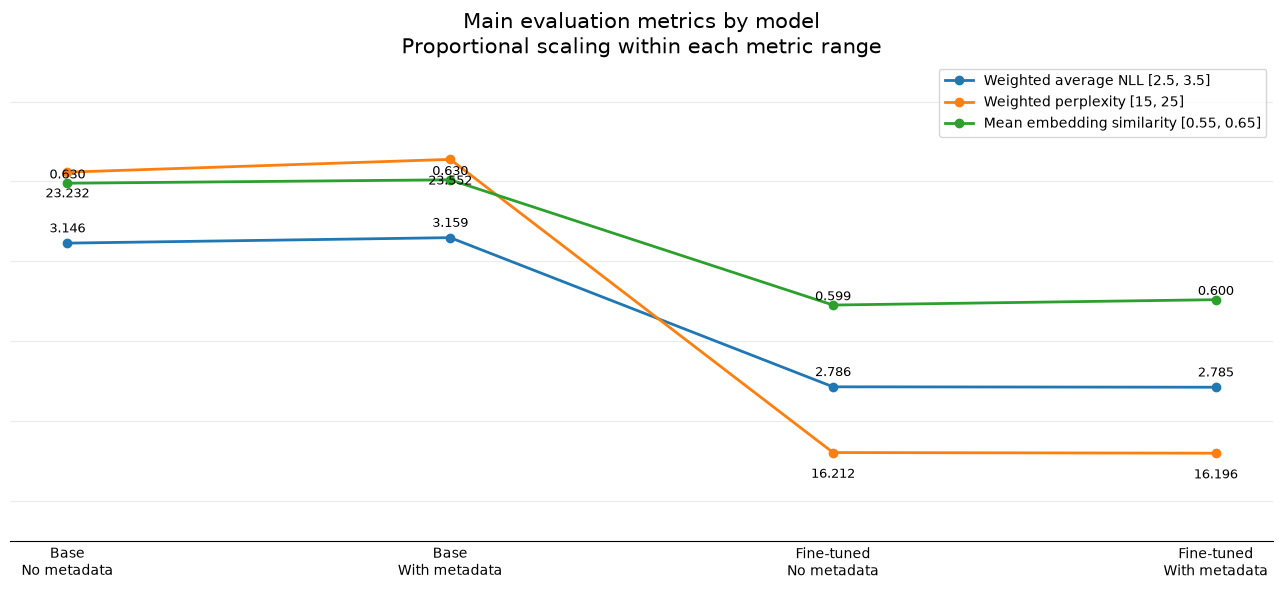

In [24]:
plot_main_metrics_one_big_graph(summary_df)

In [19]:
def plot_main_metrics_one_big_graph():
    metrics = [
        {
            "col": "weighted_avg_nll",
            "label": "Weighted average NLL",
            "subtitle": "Lower is better",
            "range": (2.5, 3.5),
            "fmt": "{:.3f}",
        },
        {
            "col": "weighted_perplexity",
            "label": "Weighted perplexity",
            "subtitle": "Lower is better",
            "range": (15, 25),
            "fmt": "{:.3f}",
        },
        {
            "col": "mean_embedding_similarity",
            "label": "Mean embedding similarity",
            "subtitle": "Higher is better",
            "range": (0.55, 0.65),
            "fmt": "{:.3f}",
        },
    ]

    if summary_df is None:
        print("Cannot plot combined metrics: summary_df is missing.")
        return

    required_cols = ["model_variant"] + [m["col"] for m in metrics]
    missing_cols = [col for col in required_cols if col not in summary_df.columns]
    if missing_cols:
        print("Cannot plot combined metrics. Missing columns:", missing_cols)
        return

    plot_df = summary_df.copy()
    plot_df["model_order"] = plot_df["model_variant"].apply(
        lambda x: MODEL_ORDER.index(x) if x in MODEL_ORDER else len(MODEL_ORDER)
    )
    plot_df = plot_df.sort_values("model_order")

    x = list(range(len(plot_df)))
    xlabels = _label_models(plot_df["model_variant"])

    plt.figure(figsize=(12, 6))

    for m in metrics:
        values = plot_df[m["col"]].values
        lo, hi = m["range"]

        # normalize to proportional position inside the chosen range
        norm_values = (values - lo) / (hi - lo)

        plt.plot(
            x,
            norm_values,
            marker="o",
            linewidth=2,
            label=f'{m["label"]} [{lo}, {hi}]'
        )

        for xi, yi, raw in zip(x, norm_values, values):
            plt.text(
                xi,
                yi + 0.03,
                m["fmt"].format(raw),
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.xticks(x, xlabels)
    plt.ylim(-0.05, 1.08)

    # minimal look
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    plt.tick_params(axis="y", left=False, labelleft=False)
    plt.tick_params(axis="x", length=0)
    plt.grid(axis="y", alpha=0.25)

    plt.title("Main evaluation metrics by model\n(proportional scaling within each metric range)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. Load optional dream dataset

The dataset is used only for:

- recovering the list of available metadata values;
- sampling an example dream beginning and its metadata for the interface.

The model can generate even if the dataset CSV is missing.

In [8]:
DEFAULT_METADATA_VALUES = {
    "dominant_macro_emotion": [
        "admiration_approval", "embarrassment_confusion", "joy_amusement", "fear_anxiety",
        "anger_frustration", "disappointment_remorse", "sadness_grief", "curiosity_surprise",
        "optimism_desire", "disgust_disapproval", "love_caring", "excitement_pride", "gratitude_relief",
    ],
    "second_dominant_macro_emotion": [
        "admiration_approval", "anger_frustration", "disappointment_remorse", "joy_amusement",
        "embarrassment_confusion", "sadness_grief", "curiosity_surprise", "disgust_disapproval",
        "fear_anxiety", "optimism_desire", "excitement_pride", "love_caring", "gratitude_relief",
    ],
    "dream_topic": ["unknown"],
    "sex": ["female", "male", "mixed_or_group"],
    "age": [
        "unknown", "child", "adolescent", "young_adult", "adult", "middle_aged",
        "older_adult", "mixed_or_group", "longitudinal_multiple_ages",
    ],
}

def find_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    for col in candidates:
        if col in df.columns:
            return col
    return None

def split_dream_report(text: str, ratio: float = 0.70) -> Tuple[str, str]:
    words = str(text).split()
    if len(words) < 2:
        return str(text).strip(), ""
    split_idx = int(len(words) * ratio)
    split_idx = max(1, min(split_idx, len(words) - 1))
    prefix = " ".join(words[:split_idx]).strip()
    continuation = " ".join(words[split_idx:]).strip()
    return prefix, continuation

def valid_metadata_values(series: pd.Series) -> List[str]:
    values = series.dropna().astype(str).str.strip()
    values = values[(values != "") & (~values.str.lower().isin(["nan", "none", "null"]))]
    return sorted(values.unique().tolist())

df_dreams = None
TEXT_COL = None
available_metadata_values = {col: DEFAULT_METADATA_VALUES.get(col, ["unknown"]).copy() for col in METADATA_COLS}

if DREAM_CSV_PATH.exists():
    df_dreams = pd.read_csv(DREAM_CSV_PATH)
    TEXT_COL = find_column(df_dreams, TEXT_COL_CANDIDATES)
    missing_metadata = [col for col in METADATA_COLS if col not in df_dreams.columns]

    print("Loaded dream dataset:", DREAM_CSV_PATH)
    print("Shape:", df_dreams.shape)
    print("Text column:", TEXT_COL)
    print("Metadata columns:", METADATA_COLS)

    if missing_metadata:
        print("WARNING: missing metadata columns:", missing_metadata)
        print("The interface will use fallback values for missing columns.")

    for col in METADATA_COLS:
        if col in df_dreams.columns:
            values = valid_metadata_values(df_dreams[col])
            if values:
                available_metadata_values[col] = values

    display(df_dreams.head())
else:
    print("Dream CSV not found. Generation will still work, but no dataset examples will be available.")

print("Available metadata values:")
for col, values in available_metadata_values.items():
    preview = values[:15]
    suffix = " ..." if len(values) > 15 else ""
    print(f"- {col}: {preview}{suffix}")

Loaded dream dataset: dream_clean_emotion_topic_metadata.csv
Shape: (21000, 6)
Text column: dream_text
Metadata columns: ['dominant_macro_emotion', 'second_dominant_macro_emotion', 'dream_topic', 'sex', 'age']


,dream_text,dominant_macro_emotion,second_dominant_macro_emotion,dream_topic,sex,age
0,"The one at the Meads's house, where it's bigge...",admiration_approval,joy_amusement,topic_02_wheelchair_bonnie_yarn_dovre,female,adult
1,I'm at a family reunion in a large fine house ...,sadness_grief,disappointment_remorse,topic_15_ski_pilot_tornado_clouds,female,adult
2,I watch a plane fly past and shortly realize i...,embarrassment_confusion,disgust_disapproval,topic_15_ski_pilot_tornado_clouds,female,adult
3,Me pulling the green leaves and berries off so...,embarrassment_confusion,admiration_approval,topic_17_kitten_kittens_patio_plant,female,adult
4,I'm in a room that reminds me of (but definite...,embarrassment_confusion,curiosity_surprise,topic_02_wheelchair_bonnie_yarn_dovre,female,adult


Available metadata values:
- dominant_macro_emotion: ['admiration_approval', 'anger_frustration', 'curiosity_surprise', 'disappointment_remorse', 'disgust_disapproval', 'embarrassment_confusion', 'excitement_pride', 'fear_anxiety', 'gratitude_relief', 'joy_amusement', 'love_caring', 'optimism_desire', 'sadness_grief']
- second_dominant_macro_emotion: ['admiration_approval', 'anger_frustration', 'curiosity_surprise', 'disappointment_remorse', 'disgust_disapproval', 'embarrassment_confusion', 'excitement_pride', 'fear_anxiety', 'gratitude_relief', 'joy_amusement', 'love_caring', 'optimism_desire', 'sadness_grief']
- dream_topic: ['topic_00_passenger_highway_drivers_driving_car', 'topic_01_ms_exam_math_elijah', 'topic_02_wheelchair_bonnie_yarn_dovre', 'topic_03_aliens_enemy_guns_shooting', 'topic_04_cookies_bread_grocery_store_pan', 'topic_05_nana_nanas_poppa_darren', 'topic_06_deer_snake_hunting_bear', 'topic_07_zombies_vampire_cinema_zombie', 'topic_08_make_love_penis_sexually_annie', '

## 7. Extract and locate LoRA adapter folders

Your fine-tuning output is a **LoRA adapter zip**, not a full standalone model. This cell extracts it if needed and searches for the two expected adapter folders.

In [9]:
def find_adapter_dir(adapter_name: str, verbose: bool = True) -> Optional[Path]:
    direct_candidates = [
        FINETUNED_ROOT / "final_adapters" / adapter_name,
        Path("final_adapters") / adapter_name,
        Path(adapter_name),
    ]
    
    for candidate in direct_candidates:
        if (candidate / "adapter_config.json").exists():
            if verbose:
                print(f"Found {adapter_name}: {candidate}")
            return candidate
    
    matches = []
    for config_path in Path(".").rglob("adapter_config.json"):
        if config_path.parent.name == adapter_name:
            matches.append(config_path.parent)
    
    if matches:
        if verbose:
            print(f"Found {adapter_name}: {matches[0]}")
        return matches[0]
    
    return None

def extract_zip_if_needed(zip_path: Path) -> None:
    adapter_a = find_adapter_dir(ADAPTER_A_NAME, verbose=False)
    adapter_b = find_adapter_dir(ADAPTER_B_NAME, verbose=False)
    if adapter_a is not None and adapter_b is not None:
        print("Both adapter folders are already available. No extraction needed.")
        return
    
    if not zip_path.exists():
        raise FileNotFoundError(
            f"Adapter zip not found: {zip_path}. Put qwen3_dream_final_lora_adapters.zip "
            "in this notebook folder or update ADAPTER_ZIP_PATH."
        )
    
    print("Extracting adapter zip:", zip_path)
    shutil.unpack_archive(str(zip_path), ".")
    print("Extraction completed.")

def validate_lora_adapter(adapter_dir: Path, expected_base_model: str = BASE_MODEL_NAME) -> Dict[str, object]:
    config_path = adapter_dir / "adapter_config.json"
    safetensors_path = adapter_dir / "adapter_model.safetensors"
    bin_path = adapter_dir / "adapter_model.bin"
    
    report = {
        "adapter_dir": str(adapter_dir),
        "has_adapter_config": config_path.exists(),
        "has_adapter_weights": safetensors_path.exists() or bin_path.exists(),
        "base_model_in_config": None,
        "base_model_matches": None,
        "usable": False,
    }
    
    if config_path.exists():
        with open(config_path, "r", encoding="utf-8") as f:
            cfg = json.load(f)
        base_model_in_config = cfg.get("base_model_name_or_path")
        report["base_model_in_config"] = base_model_in_config
        report["base_model_matches"] = (
            base_model_in_config is None
            or str(base_model_in_config).rstrip("/") == str(expected_base_model).rstrip("/")
        )
    
    report["usable"] = bool(
        report["has_adapter_config"]
        and report["has_adapter_weights"]
        and report["base_model_matches"] is not False
    )
    return report

extract_zip_if_needed(ADAPTER_ZIP_PATH)

ADAPTER_A_DIR = find_adapter_dir(ADAPTER_A_NAME)
ADAPTER_B_DIR = find_adapter_dir(ADAPTER_B_NAME)

if ADAPTER_A_DIR is None or ADAPTER_B_DIR is None:
    raise FileNotFoundError(
        f"Could not find both adapters. Expected folders named {ADAPTER_A_NAME} and {ADAPTER_B_NAME}."
    )

adapter_report_df = pd.DataFrame([
    validate_lora_adapter(ADAPTER_A_DIR),
    validate_lora_adapter(ADAPTER_B_DIR),
])

display(adapter_report_df)

if not adapter_report_df["usable"].all():
    raise ValueError("At least one LoRA adapter is incomplete or incompatible.")

print("Adapters ready.")

Both adapter folders are already available. No extraction needed.
Found final_A_no_metadata: final_adapters\final_A_no_metadata
Found final_B_with_metadata: final_adapters\final_B_with_metadata


,adapter_dir,has_adapter_config,has_adapter_weights,base_model_in_config,base_model_matches,usable
0,final_adapters\final_A_no_metadata,True,True,Qwen/Qwen3-1.7B-Base,True,True
1,final_adapters\final_B_with_metadata,True,True,Qwen/Qwen3-1.7B-Base,True,True


Adapters ready.


## 8. Model loading utilities

The model is loaded **on demand**. This is important because loading all variants at once may use too much RAM/VRAM.

In [10]:
def clear_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

def get_compute_dtype():
    if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
        return torch.bfloat16
    if torch.cuda.is_available():
        return torch.float16
    return torch.float32

def make_quantization_config():
    if not USE_4BIT:
        return None
    if not torch.cuda.is_available():
        return None
    if BitsAndBytesConfig is None:
        return None
    
    try:
        import bitsandbytes  # noqa: F401
    except Exception as exc:
        print("bitsandbytes not available. Falling back to non-4-bit loading.")
        print("Reason:", repr(exc))
        return None
    
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=get_compute_dtype(),
    )

def load_tokenizer(tokenizer_source=None):
    source = tokenizer_source if tokenizer_source is not None else BASE_MODEL_NAME
    tokenizer = AutoTokenizer.from_pretrained(str(source), trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    return tokenizer

def model_loading_kwargs() -> Dict[str, object]:
    kwargs = {
        "trust_remote_code": True,
        "torch_dtype": get_compute_dtype(),
    }
    
    quantization_config = make_quantization_config()
    if quantization_config is not None:
        kwargs["quantization_config"] = quantization_config
        kwargs["device_map"] = "auto"
    elif torch.cuda.is_available():
        kwargs["device_map"] = "auto"
    
    return kwargs

def load_base_model_and_tokenizer():
    clear_memory()
    tokenizer = load_tokenizer(BASE_MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME, **model_loading_kwargs())
    model.eval()
    return model, tokenizer

def load_lora_model_and_tokenizer(adapter_dir: Path):
    clear_memory()
    adapter_dir = Path(adapter_dir)
    tokenizer_source = adapter_dir if (adapter_dir / "tokenizer_config.json").exists() else BASE_MODEL_NAME
    tokenizer = load_tokenizer(tokenizer_source)
    base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME, **model_loading_kwargs())
    model = PeftModel.from_pretrained(base_model, str(adapter_dir))
    model.eval()
    return model, tokenizer

def get_model_device(model):
    return next(model.parameters()).device

## 9. Prompt template and generation function

This uses the same prompt structure as training/evaluation: the metadata-conditioned variants receive a `Dream metadata` block with dominant emotion, second emotion, topic, sex, and age.

In [11]:
METADATA_LABELS = {
    "dominant_macro_emotion": "dominant_macro_emotion",
    "second_dominant_macro_emotion": "second_dominant_macro_emotion",
    "dream_topic": "dream_topic",
    "sex": "sex",
    "age": "age",
}


def clean_metadata_value(value: object) -> str:
    value = str(value).strip()
    if value == "" or value.lower() in {"nan", "none", "null"}:
        return "unknown"
    return value


def format_metadata_block(metadata: Dict[str, object]) -> str:
    lines = ["Dream metadata:"]
    for col in METADATA_COLS:
        label = METADATA_LABELS.get(col, col)
        value = clean_metadata_value(metadata.get(col, "unknown"))
        lines.append(f"- {label}: {value}")
    return "\n".join(lines)


def make_prompt(prefix: str, metadata: Optional[Dict[str, object]] = None) -> str:
    prefix = str(prefix).strip()
    if metadata is None:
        return (
            "Dream beginning:\n"
            f"{prefix}\n\n"
            "Dream continuation:\n"
        )

    return (
        f"{format_metadata_block(metadata)}\n\n"
        "Dream beginning:\n"
        f"{prefix}\n\n"
        "Dream continuation:\n"
    )

MODEL_VARIANTS = {
    "base_no_metadata": {
        "label": "Base Qwen3 — no metadata",
        "adapter_dir": None,
        "uses_metadata": False,
    },
    "base_with_metadata": {
        "label": "Base Qwen3 — with metadata",
        "adapter_dir": None,
        "uses_metadata": True,
    },
    "finetuned_no_metadata": {
        "label": "Fine-tuned Qwen3 LoRA A — no metadata",
        "adapter_dir": ADAPTER_A_DIR,
        "uses_metadata": False,
    },
    "finetuned_with_metadata": {
        "label": "Fine-tuned Qwen3 LoRA B — with metadata",
        "adapter_dir": ADAPTER_B_DIR,
        "uses_metadata": True,
    },
}

ENGINE_CACHE = {
    "variant_key": None,
    "model": None,
    "tokenizer": None,
}

def unload_current_model():
    if ENGINE_CACHE["model"] is not None:
        del ENGINE_CACHE["model"]
    if ENGINE_CACHE["tokenizer"] is not None:
        del ENGINE_CACHE["tokenizer"]
    ENGINE_CACHE["variant_key"] = None
    ENGINE_CACHE["model"] = None
    ENGINE_CACHE["tokenizer"] = None
    clear_memory()

def load_engine_model(variant_key: str):
    if variant_key not in MODEL_VARIANTS:
        raise ValueError(f"Unknown variant: {variant_key}")

    if ENGINE_CACHE["variant_key"] == variant_key and ENGINE_CACHE["model"] is not None:
        return ENGINE_CACHE["model"], ENGINE_CACHE["tokenizer"]

    if LOAD_ONE_MODEL_AT_A_TIME:
        unload_current_model()

    variant = MODEL_VARIANTS[variant_key]
    print(f"Loading model: {variant['label']}")

    if variant["adapter_dir"] is None:
        model, tokenizer = load_base_model_and_tokenizer()
    else:
        model, tokenizer = load_lora_model_and_tokenizer(variant["adapter_dir"])

    ENGINE_CACHE["variant_key"] = variant_key
    ENGINE_CACHE["model"] = model
    ENGINE_CACHE["tokenizer"] = tokenizer
    return model, tokenizer

def generate_one_continuation(
    prefix: str,
    variant_key: str,
    metadata: Optional[Dict[str, object]] = None,
    max_new_tokens: int = DEFAULT_MAX_NEW_TOKENS,
    temperature: float = DEFAULT_TEMPERATURE,
    top_p: float = DEFAULT_TOP_P,
    repetition_penalty: float = DEFAULT_REPETITION_PENALTY,
) -> str:
    prefix = str(prefix).strip()
    if not prefix:
        raise ValueError("Please write the first part of the dream.")

    variant = MODEL_VARIANTS[variant_key]
    metadata_for_prompt = metadata if variant["uses_metadata"] else None
    if variant["uses_metadata"] and not metadata_for_prompt:
        raise ValueError("This variant uses metadata. Please select all metadata values.")

    model, tokenizer = load_engine_model(variant_key)
    prompt = make_prompt(prefix, metadata=metadata_for_prompt)

    prompt_max_length = max(64, MAX_LENGTH - int(max_new_tokens))
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=prompt_max_length,
    )

    device = get_model_device(model)
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=int(max_new_tokens),
            do_sample=True,
            temperature=float(temperature),
            top_p=float(top_p),
            repetition_penalty=float(repetition_penalty),
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    continuation = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return continuation

## 10. Quick test without the interface

Run this cell before Gradio to check that loading and generation work.

The first run can take time because the model must be downloaded from Hugging Face or loaded from cache.

In [12]:
test_prefix = "I was walking through a strange city at night, and suddenly I realized that all the streets were changing direction."
test_metadata = {col: available_metadata_values[col][0] for col in METADATA_COLS}

print("Metadata used:", test_metadata)
print("\nPrompt preview:\n")
print(make_prompt(test_prefix, metadata=test_metadata))

# Uncomment one of these lines for a quick test.
# print(generate_one_continuation(test_prefix, "finetuned_no_metadata", max_new_tokens=80))
# print(generate_one_continuation(test_prefix, "finetuned_with_metadata", metadata=test_metadata, max_new_tokens=80))

Metadata used: {'dominant_macro_emotion': 'admiration_approval', 'second_dominant_macro_emotion': 'admiration_approval', 'dream_topic': 'topic_00_passenger_highway_drivers_driving_car', 'sex': 'female', 'age': 'adolescent'}

Prompt preview:

Dream metadata:
- dominant_macro_emotion: admiration_approval
- second_dominant_macro_emotion: admiration_approval
- dream_topic: topic_00_passenger_highway_drivers_driving_car
- sex: female
- age: adolescent

Dream beginning:
I was walking through a strange city at night, and suddenly I realized that all the streets were changing direction.

Dream continuation:



## 11. Helper: sample a dream beginning from your dataset

This is useful for testing the interface with real examples from your CSV.

In [13]:
def extract_metadata_from_sample(sampled: pd.Series) -> Dict[str, str]:
    metadata = {}
    for col in METADATA_COLS:
        if col in sampled.index:
            value = clean_metadata_value(sampled[col])
            if value == "unknown" and available_metadata_values.get(col):
                value = available_metadata_values[col][0]
        else:
            value = available_metadata_values[col][0]
        metadata[col] = value
    return metadata

def sample_dream_beginning() -> Tuple[str, Dict[str, str]]:
    if df_dreams is None or TEXT_COL is None:
        return "", {col: available_metadata_values[col][0] for col in METADATA_COLS}

    sampled = df_dreams.dropna(subset=[TEXT_COL]).sample(1, random_state=None).iloc[0]
    full_text = str(sampled[TEXT_COL]).strip()
    prefix, _ = split_dream_report(full_text, ratio=0.70)
    metadata = extract_metadata_from_sample(sampled)
    return prefix, metadata

sample_prefix, sample_metadata = sample_dream_beginning()
print("Sample metadata:", sample_metadata)
print("Sample prefix:")
print(sample_prefix[:1000])

Sample metadata: {'dominant_macro_emotion': 'curiosity_surprise', 'second_dominant_macro_emotion': 'admiration_approval', 'dream_topic': 'topic_02_wheelchair_bonnie_yarn_dovre', 'sex': 'female', 'age': 'middle_aged'}
Sample prefix:
I have acquired a large mansion with extensive lawns and gardens of a formal nature. I am well dressed, slim and trim, in black patent leather heels, black skirt and a purple and black flowered halter top with spaghetti straps. I look out over the vast lawn and see African dancers. I am surprised they aren't Native American like I'm used to, but realize things move on and this must be honored as well. I go out to dance with them, but stay on the outskirts of the huge circle of dancers, being careful not to be disrespectful and intrusive, but wanting to be a part of it all. I dance South American calypso kinds of steps. After that, I decide to go see how the man I've hired to clean up and weed the garden area is doing. He's been there two days now and I think

## 12. Gradio interactive interface

This interface runs locally from VS Code and lets you select every metadata field: dominant emotion, second dominant emotion, topic, sex, and age.

In [14]:
try:
    demo.close()
except Exception:
    pass


def format_generation_output(title: str, text: str) -> str:
    safe_text = text.strip() if text and text.strip() else "_Empty output. Try increasing max tokens or temperature._"
    return f"### {title}\n\n{safe_text}"


def make_status_html(percent: int, message: str) -> str:
    percent = max(0, min(100, int(percent)))
    return f"""
    <div style="
        border: 1px solid #ddd;
        border-radius: 10px;
        padding: 14px;
        margin-top: 12px;
        background: #fafafa;
    ">
        <div style="font-weight: 700; margin-bottom: 8px;">
            {message}
        </div>

        <div style="
            width: 100%;
            height: 24px;
            background: #e6e6e6;
            border-radius: 12px;
            overflow: hidden;
        ">
            <div style="
                width: {percent}%;
                height: 100%;
                background: #ff6a00;
                transition: width 0.3s ease;
            "></div>
        </div>

        <div style="margin-top: 6px; font-size: 14px; color: #555;">
            Progress: {percent}%
        </div>
    </div>
    """


def build_metadata_dict(
    dominant_macro_emotion: str,
    second_dominant_macro_emotion: str,
    dream_topic: str,
    sex: str,
    age: str,
) -> Dict[str, str]:
    return {
        "dominant_macro_emotion": dominant_macro_emotion,
        "second_dominant_macro_emotion": second_dominant_macro_emotion,
        "dream_topic": dream_topic,
        "sex": sex,
        "age": age,
    }


def run_interactive_generation(
    dream_beginning: str,
    dominant_macro_emotion: str,
    second_dominant_macro_emotion: str,
    dream_topic: str,
    sex: str,
    age: str,
    mode: str,
    max_new_tokens: int,
    temperature: float,
    top_p: float,
    repetition_penalty: float,
):
    metadata = build_metadata_dict(
        dominant_macro_emotion=dominant_macro_emotion,
        second_dominant_macro_emotion=second_dominant_macro_emotion,
        dream_topic=dream_topic,
        sex=sex,
        age=age,
    )

    try:
        yield (
            "Output will appear here after generation.",
            make_status_html(5, "Preparing input and metadata...")
        )

        if mode == "Single: base no metadata":
            yield (
                "Output will appear here after generation.",
                make_status_html(25, "Generating with base model without metadata...")
            )

            text = generate_one_continuation(
                dream_beginning,
                "base_no_metadata",
                metadata=None,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=top_p,
                repetition_penalty=repetition_penalty,
            )

            yield (
                format_generation_output("Base Qwen3 — no metadata", text),
                make_status_html(100, "Done.")
            )
            return

        if mode == "Single: base with metadata":
            yield (
                "Output will appear here after generation.",
                make_status_html(25, "Generating with base model using metadata...")
            )

            text = generate_one_continuation(
                dream_beginning,
                "base_with_metadata",
                metadata=metadata,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=top_p,
                repetition_penalty=repetition_penalty,
            )

            yield (
                format_generation_output("Base Qwen3 — with metadata", text),
                make_status_html(100, "Done.")
            )
            return

        if mode == "Single: fine-tuned no metadata":
            yield (
                "Output will appear here after generation.",
                make_status_html(25, "Generating with fine-tuned model A without metadata...")
            )

            text = generate_one_continuation(
                dream_beginning,
                "finetuned_no_metadata",
                metadata=None,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=top_p,
                repetition_penalty=repetition_penalty,
            )

            yield (
                format_generation_output("Fine-tuned Qwen3 LoRA A — no metadata", text),
                make_status_html(100, "Done.")
            )
            return

        if mode == "Single: fine-tuned with metadata":
            yield (
                "Output will appear here after generation.",
                make_status_html(25, "Generating with fine-tuned model B using metadata...")
            )

            text = generate_one_continuation(
                dream_beginning,
                "finetuned_with_metadata",
                metadata=metadata,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=top_p,
                repetition_penalty=repetition_penalty,
            )

            yield (
                format_generation_output("Fine-tuned Qwen3 LoRA B — with metadata", text),
                make_status_html(100, "Done.")
            )
            return

        if mode == "Compare fine-tuned A vs B":
            outputs = []

            yield (
                "Output will appear here after generation.",
                make_status_html(10, "Step 1/2 — Generating fine-tuned A without metadata...")
            )

            text_a = generate_one_continuation(
                dream_beginning,
                "finetuned_no_metadata",
                metadata=None,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=top_p,
                repetition_penalty=repetition_penalty,
            )

            outputs.append(
                format_generation_output("Fine-tuned A — no metadata", text_a)
            )

            yield (
                "\n\n---\n\n".join(outputs),
                make_status_html(55, "Step 2/2 — Generating fine-tuned B with metadata...")
            )

            text_b = generate_one_continuation(
                dream_beginning,
                "finetuned_with_metadata",
                metadata=metadata,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=top_p,
                repetition_penalty=repetition_penalty,
            )

            outputs.append(
                format_generation_output(
                    f"Fine-tuned B — with metadata: `{format_metadata_block(metadata)}`",
                    text_b,
                )
            )

            yield (
                "\n\n---\n\n".join(outputs),
                make_status_html(100, "Done. Both fine-tuned variants completed.")
            )
            return

        if mode == "Compare all four variants":
            outputs = []

            ordered_keys = [
                "base_no_metadata",
                "base_with_metadata",
                "finetuned_no_metadata",
                "finetuned_with_metadata",
            ]

            total_variants = len(ordered_keys)

            for i, key in enumerate(ordered_keys):
                variant = MODEL_VARIANTS[key]

                current_percent = int((i / total_variants) * 100)
                next_step = i + 1

                partial_output = "\n\n---\n\n".join(outputs) if outputs else "Output will appear here after generation."

                yield (
                    partial_output,
                    make_status_html(
                        current_percent,
                        f"Step {next_step}/{total_variants} — Generating {variant['label']}..."
                    )
                )

                text = generate_one_continuation(
                    dream_beginning,
                    key,
                    metadata=metadata if variant["uses_metadata"] else None,
                    max_new_tokens=max_new_tokens,
                    temperature=temperature,
                    top_p=top_p,
                    repetition_penalty=repetition_penalty,
                )

                title = variant["label"]

                if variant["uses_metadata"]:
                    title += " | metadata used"

                outputs.append(format_generation_output(title, text))

                completed_percent = int(((i + 1) / total_variants) * 100)

                yield (
                    "\n\n---\n\n".join(outputs),
                    make_status_html(
                        completed_percent,
                        f"Completed {next_step}/{total_variants} variants."
                    )
                )

            yield (
                "\n\n---\n\n".join(outputs),
                make_status_html(100, "Done. All four variants completed.")
            )
            return

        yield (
            "### Generation failed\n\nUnknown generation mode.",
            make_status_html(100, f"Unknown mode: {mode}")
        )

    except Exception as exc:
        yield (
            f"### Generation failed\n\n```text\n{repr(exc)}\n```",
            make_status_html(100, "Generation failed. Check the notebook output for the full error.")
        )


def gradio_sample_dream():
    prefix, metadata = sample_dream_beginning()
    return [prefix] + [metadata[col] for col in METADATA_COLS]


mode_choices = [
    "Single: fine-tuned no metadata",
    "Single: fine-tuned with metadata",
    "Compare fine-tuned A vs B",
    "Single: base no metadata",
    "Single: base with metadata",
    "Compare all four variants",
]


with gr.Blocks(title="Qwen3 Dream Continuation Engine") as demo:
    gr.Markdown("# Qwen3 Dream Continuation Engine")
    gr.Markdown(
        "Use the model already fine-tuned in Colab. "
        "The metadata-conditioned variants receive dominant emotion, second emotion, topic, sex, and age."
    )

    with gr.Row():
        with gr.Column(scale=2):
            dream_beginning_box = gr.Textbox(
                label="Dream beginning",
                lines=9,
                placeholder="Write the first part of the dream here...",
                value=sample_prefix,
            )

            sample_button = gr.Button("Use random dream from dataset")

        with gr.Column(scale=1):
            dominant_emotion_dropdown = gr.Dropdown(
                label="dominant_macro_emotion",
                choices=available_metadata_values["dominant_macro_emotion"],
                value=sample_metadata["dominant_macro_emotion"]
                if sample_metadata["dominant_macro_emotion"] in available_metadata_values["dominant_macro_emotion"]
                else available_metadata_values["dominant_macro_emotion"][0],
            )

            second_emotion_dropdown = gr.Dropdown(
                label="second_dominant_macro_emotion",
                choices=available_metadata_values["second_dominant_macro_emotion"],
                value=sample_metadata["second_dominant_macro_emotion"]
                if sample_metadata["second_dominant_macro_emotion"] in available_metadata_values["second_dominant_macro_emotion"]
                else available_metadata_values["second_dominant_macro_emotion"][0],
            )

            topic_dropdown = gr.Dropdown(
                label="dream_topic",
                choices=available_metadata_values["dream_topic"],
                value=sample_metadata["dream_topic"]
                if sample_metadata["dream_topic"] in available_metadata_values["dream_topic"]
                else available_metadata_values["dream_topic"][0],
            )

            sex_dropdown = gr.Dropdown(
                label="sex",
                choices=available_metadata_values["sex"],
                value=sample_metadata["sex"]
                if sample_metadata["sex"] in available_metadata_values["sex"]
                else available_metadata_values["sex"][0],
            )

            age_dropdown = gr.Dropdown(
                label="age",
                choices=available_metadata_values["age"],
                value=sample_metadata["age"]
                if sample_metadata["age"] in available_metadata_values["age"]
                else available_metadata_values["age"][0],
            )

            mode_dropdown = gr.Dropdown(
                label="Generation mode",
                choices=mode_choices,
                value="Compare fine-tuned A vs B",
            )

            max_tokens_slider = gr.Slider(
                label="Max new tokens",
                minimum=30,
                maximum=300,
                step=10,
                value=DEFAULT_MAX_NEW_TOKENS,
            )

            temperature_slider = gr.Slider(
                label="Temperature",
                minimum=0.10,
                maximum=1.50,
                step=0.05,
                value=DEFAULT_TEMPERATURE,
            )

            top_p_slider = gr.Slider(
                label="Top-p",
                minimum=0.10,
                maximum=1.00,
                step=0.05,
                value=DEFAULT_TOP_P,
            )

            repetition_penalty_slider = gr.Slider(
                label="Repetition penalty",
                minimum=1.00,
                maximum=1.30,
                step=0.01,
                value=DEFAULT_REPETITION_PENALTY,
            )

            generate_button = gr.Button(
                "Generate dream continuation",
                variant="primary",
            )

    status_html = gr.HTML(
        value=make_status_html(0, "Ready."),
        label="Generation status",
    )

    output_markdown = gr.Markdown(
        value="Output will appear here after generation.",
        label="Generated continuation",
    )

    sample_button.click(
        fn=gradio_sample_dream,
        inputs=[],
        outputs=[
            dream_beginning_box,
            dominant_emotion_dropdown,
            second_emotion_dropdown,
            topic_dropdown,
            sex_dropdown,
            age_dropdown,
        ],
    )

    generate_button.click(
        fn=run_interactive_generation,
        inputs=[
            dream_beginning_box,
            dominant_emotion_dropdown,
            second_emotion_dropdown,
            topic_dropdown,
            sex_dropdown,
            age_dropdown,
            mode_dropdown,
            max_tokens_slider,
            temperature_slider,
            top_p_slider,
            repetition_penalty_slider,
        ],
        outputs=[
            output_markdown,
            status_html,
        ],
    )


demo.queue()

# share=False keeps the app local. inbrowser=True opens it in your browser when possible.
demo.launch(share=False, inbrowser=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\Users\39392\miniforge3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


## 13. Optional: unload the model from memory

Run this cell when you finish generation or before switching to another heavy task.

In [15]:
unload_current_model()
print("Model unloaded from memory.")

Model unloaded from memory.


Loading model: Fine-tuned Qwen3 LoRA A — no metadata


Exception in thread Thread-11 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\39392\miniforge3\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\39392\AppData\Roaming\Python\Python312\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\39392\miniforge3\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\39392\miniforge3\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x8a in position 11: invalid start byte
W0624 18:26:37.062000 25700 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

c:\Users\39392\miniforge3\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
c:\Users\39392\miniforge3\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loading model: Fine-tuned Qwen3 LoRA B — with metadata


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

## 14. Troubleshooting

### 1. Colab worked, but VS Code gives memory errors

Use a GPU if available. If you are on CPU, generation can be very slow and memory-heavy. Try reducing `MAX_LENGTH` and `max_new_tokens`.

### 2. `bitsandbytes` error on Windows

Set:

```python
USE_4BIT = False
```

Then restart the kernel and run the notebook again. This uses more memory, but avoids the 4-bit dependency.

### 3. Adapter folders not found

Check that `qwen3_dream_metadata_lora_adapters.zip` is in the same folder as this notebook, or update `ADAPTER_ZIP_PATH`.

After extraction, the notebook expects:

```text
final_A_no_metadata
final_B_with_metadata
```

or the same folders under:

```text
qwen3_dream_cv_final_outputs/final_adapters/
```

### 4. The metadata dropdowns are empty or contain only `unknown`

Check that `DREAM_CSV_PATH` points to the CSV containing these columns:

```text
dominant_macro_emotion
second_dominant_macro_emotion
dream_topic
sex
age
```

### 5. Important compatibility note

Use this notebook with adapters trained by the metadata fine-tuning notebook. An old adapter trained only with `dominant_macro_emotion` is not equivalent to the new metadata-conditioned adapter.